In [2]:
from utils.plots import plot_tm_roc_curve_multi_specialist
import config
import pickle
import os
from utils.dataset import load_dataset

In [3]:
_, _, _, _, _, Y_test = load_dataset(config)


=== Canny ===
Macro AUC: 0.9149
  normal: AUC = 0.918
  pneumonia: AUC = 0.911

=== Adaptive Gaussian ===
Macro AUC: 0.9667
  normal: AUC = 0.964
  pneumonia: AUC = 0.969

=== Adaptive Mean ===
Macro AUC: 0.9637
  normal: AUC = 0.961
  pneumonia: AUC = 0.966

=== Otsu ===
Macro AUC: 0.9440
  normal: AUC = 0.945
  pneumonia: AUC = 0.943

=== Thermometer ===
Macro AUC: 0.9730
  normal: AUC = 0.972
  pneumonia: AUC = 0.974

--- normal ---
Saved to pneumonia_roc_normal.svg


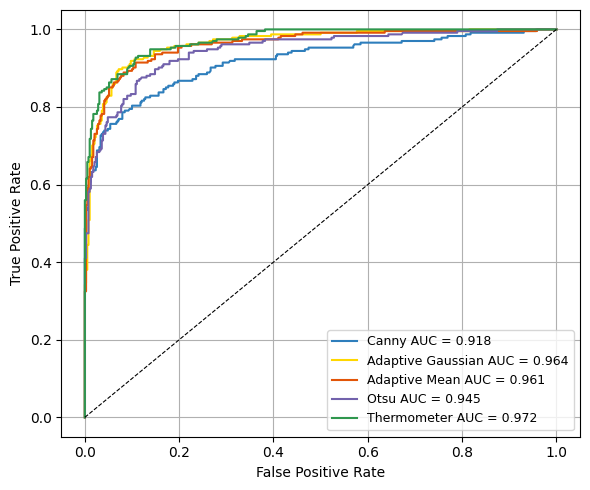


--- pneumonia ---
Saved to pneumonia_roc_pneumonia.svg


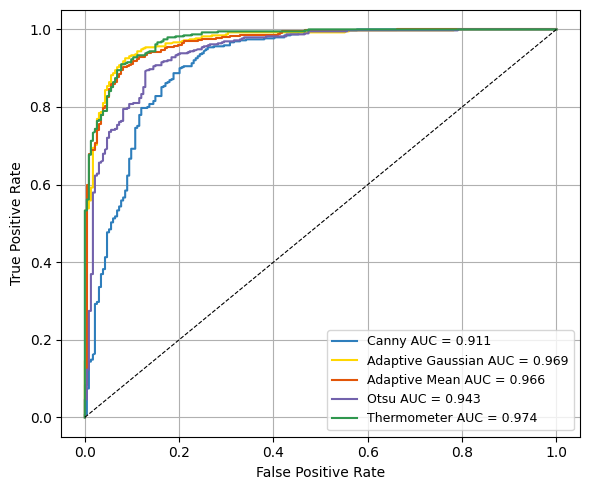

In [5]:

canny_path = os.path.join("saved_models", "PneumoniaMNIST_Canny_Specialist.pkl")
with open(canny_path, "rb") as f:
    tm_canny = pickle.load(f)
    

tm_gaussian = os.path.join("saved_models", "PneumoniaMNIST_Adaptive_Gaussian_Specialist.pkl")
with open(tm_gaussian, "rb") as f:
    tm_gaussian = pickle.load(f)

tn_mean = os.path.join("saved_models", "PneumoniaMNIST_Adaptive_Mean_Specialist.pkl") 
with open(tn_mean, "rb") as f:
    tm_mean = pickle.load(f)

tm_otsu = os.path.join("saved_models", "PneumoniaMNIST_Otsu_Specialist.pkl")
with open(tm_otsu, "rb") as f:
    tm_otsu = pickle.load(f)

tm_thermo = os.path.join("saved_models", "PneumoniaMNIST_Color_Thermometers_Specialist.pkl")
with open(tm_thermo, "rb") as f:
    tm_thermo = pickle.load(f)
    
    
    
plot_tm_roc_curve_multi_specialist(
    config=config,
   params=[
        {"T_best": tm_canny.T, "s_best": tm_canny.s, "patch_best": tm_canny.patch_dim[0],
        "maxlit_best": tm_canny.max_included_literals, "weighted_best": 1},
        {"T_best": tm_gaussian.T, "s_best": tm_gaussian.s, "patch_best": tm_gaussian.patch_dim[0],
        "maxlit_best": tm_gaussian.max_included_literals, "weighted_best": 1},
        {"T_best": tm_mean.T, "s_best": tm_mean.s, "patch_best": tm_mean.patch_dim[0],
        "maxlit_best": tm_mean.max_included_literals, "weighted_best": 1},
        {"T_best": tm_otsu.T, "s_best": tm_otsu.s, "patch_best": tm_otsu.patch_dim[0],
        "maxlit_best": tm_otsu.max_included_literals, "weighted_best": 1},
        {"T_best": tm_thermo.T, "s_best": tm_thermo.s, "patch_best": tm_thermo.patch_dim[0],
        "maxlit_best": tm_thermo.max_included_literals, "weighted_best": 1},
    ],
        # ... repeat for each specialist

    filename_prefixes=[
        "PneumoniaMNIST_Canny",
        "PneumoniaMNIST_Adaptive_Gaussian",
        "PneumoniaMNIST_Adaptive_Mean",
        "PneumoniaMNIST_Otsu",
        "PneumoniaMNIST_Color_Thermometers",
    ],
    specialist_names=["Canny", "Adaptive Gaussian", "Adaptive Mean", "Otsu", "Thermometer"],
    Y_test=Y_test,
    class_names=["normal", "pneumonia"],
    save_path="pneumonia_roc.svg"
)